In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import gurobipy as gp
from gurobipy import GRB
import matplotlib.patches as patches
from collections import deque
from matplotlib.legend_handler import HandlerTuple
from matplotlib.lines import Line2D

## Import Data and Calculate Variability Bounds

In [2]:
### import network
BB = np.load('SCE56_network.npy')
YY = np.load('SCE56_network_admitance.npy')
num_node = BB.shape[0]

In [3]:
### import data
p_arr = np.load('HICSS_data_load_p.npy')
q_arr = np.load('HICSS_data_load_q.npy')

p_pv_arr = np.load('HICSS_data_pv_p.npy')
q_pv_arr = np.load('HICSS_data_pv_q.npy')

horizon = p_pv_arr.shape[1]

In [4]:
### Calculate the power variability bounds
scale_factor = 1

load_var_upp = 0.6  * scale_factor
load_var_low = 0.6 * scale_factor
pvp_var_upp = 1 * scale_factor
pvq_var_upp = 1 * scale_factor
pvq_var_low = 1.5 * scale_factor

p_load_upp = np.empty(num_node)
p_load_low = np.empty(num_node)
q_load_upp = np.empty(num_node)
q_load_low = np.empty(num_node)

for i in range(num_node):
    p_load_upp[i] = p_arr[i, 0] * (1 + load_var_upp)
    p_load_low[i] = p_arr[i, 0] * (1 - load_var_low)
    if q_arr[i, 0] > 0:
        q_load_upp[i] = q_arr[i, 0] * (1 + load_var_upp)
        q_load_low[i] = q_arr[i, 0] * (1 - load_var_low)
    else: 
        q_load_upp[i] = q_arr[i, 0]
        q_load_low[i] = q_arr[i, 0]

p_pv_upp = np.empty(num_node)
p_pv_low = np.empty(num_node)
q_pv_upp = np.empty(num_node)
q_pv_low = np.empty(num_node)


for i in range(num_node):
    p_pv_upp[i] = p_pv_arr[i, 0] * (1 + pvp_var_upp)
    p_pv_low[i] = p_pv_arr[i, 0] * 0
    q_pv_upp[i] = q_pv_arr[i, 0] * (1 + pvq_var_upp)
    q_pv_low[i] = q_pv_arr[i, 0] * (1 - pvq_var_low)

In [5]:
x1 = np.hstack([(p_pv_low - p_load_upp), (q_pv_low - q_load_upp)])    # lower bound
x2 = np.hstack([(p_pv_upp - p_load_low), (q_pv_upp - q_load_low)])    # upper bound

## Classification of Voltage Measurements

In [6]:
### Problem set up
# [18, 29] for figure 1 a
# [5, 11] for figure 1 b

node_obs = [18, 29]
num_obs = len(node_obs)
target_node = 40

### extreme voltage shift
vm_low = BB[node_obs] @ x1
vm_high = BB[node_obs] @ x2

print(vm_low + 1)
print(vm_high + 1)

[0.9538521  0.89506813]
[1.04340852 1.11581976]


### Pure Region Classification

In [7]:
resol = 100

z1 = np.linspace(1 + vm_low[0], 1 + vm_high[0], resol)
z2 = np.linspace(1 + vm_low[1], 1 + vm_high[1], resol)

# data collection
feasible_set = []
num_feasible = 0

safe_set = []
unsafe_set = []
safe_value = []
num_safe = 0


xx = cp.Variable(2 * num_node)

obj1 = cp.Maximize(BB[target_node, :] @ xx + 1)

vm = cp.Parameter(len(node_obs))

constraint = [x1 <= xx]
constraint += [xx <= x2]

constraint += [BB[node_obs[0], :] @ xx + 1 == vm[0]]
constraint += [BB[node_obs[1], :] @ xx + 1 == vm[1]]

problem = cp.Problem(obj1, constraint)

for i in range(resol):
    for j in range(resol):
        vm.value = np.array([z1[i], z2[j]])

        problem.solve(
        solver=cp.GUROBI,
        warm_start=True,
        verbose=False)
        
        vv5 = np.array(problem.value)

        status = problem.status
        #print(status)

        if 'optimal' == status:
            feasible_set.append(np.array([z1[i], z2[j]]))
            num_feasible +=1
            if vv5 <= 1 + 0.05:
                safe_set.append(np.array([z1[i], z2[j]]))
                safe_value.append(vv5)
                num_safe += 1
            else:
                unsafe_set.append(np.array([z1[i], z2[j]]))

Set parameter Username
Academic license - for non-commercial use only - expires 2027-04-15


/opt/homebrew/lib/python3.11/site-packages/cvxpy/problems/problem.py:1545: UserWarning: 
    The problem is either infeasible or unbounded, but the solver
    cannot tell which. Disable any solver-specific presolve methods
    and re-solve to determine the precise problem status.

    For GUROBI and CPLEX you can automatically perform this re-solve
    with the keyword argument prob.solve(reoptimize=True, ...).
    
  warnings.warn(INF_OR_UNB_MESSAGE)


In [8]:
### Lower limit safety
safe_set_min = []
unsafe_set_min = []
safe_value_min = []
num_safe_min = 0

xx = cp.Variable(2 * num_node)

obj1 = cp.Minimize(BB[target_node, :] @ xx + 1)

vm = cp.Parameter(len(node_obs))

constraint = [x1 <= xx]
constraint += [xx <= x2]

constraint += [BB[node_obs[0], :] @ xx + 1 == vm[0]]
constraint += [BB[node_obs[1], :] @ xx + 1 == vm[1]]

problem = cp.Problem(obj1, constraint)


for volt in feasible_set:
    vm.value = np.array([volt[0], volt[1]])

    problem.solve(solver=cp.GUROBI,
    warm_start=True,
    verbose=False)
    
    vv5 = np.array(problem.value)

    if vv5 >= 1 - 0.05:
        safe_set_min.append(np.array([volt[0], volt[1]]))
        safe_value_min.append(vv5)
        num_safe_min += 1
    else:
        unsafe_set_min.append(np.array([volt[0], volt[1]]))

In [9]:
# Convert arrays to tuples for hashing
safe_set_min = {tuple(arr) for arr in safe_set_min}

# Retain arrays from list_a present in list_b (preserves original order and array types)
safe_set_both = [arr for arr in safe_set if tuple(arr) in safe_set_min]

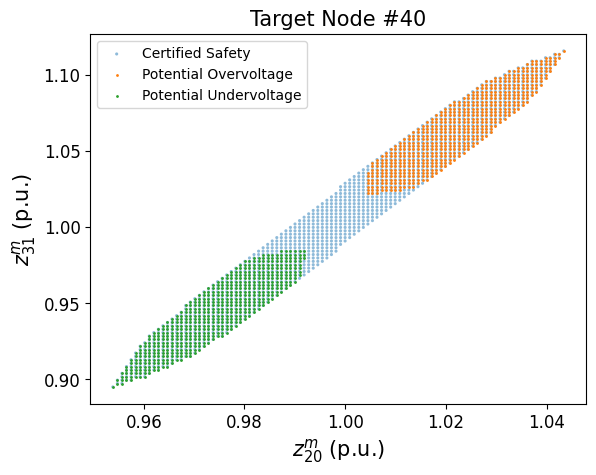

In [10]:
### Plot the 2-d region
feasible_set_x = []
feasible_set_y = []
unsafe_set_x = []
unsafe_set_y = []
unsafe_set_min_x = []
unsafe_set_min_y = []
actual_set_x = []
actual_set_y = []
safe_set_both_x = []
safe_set_both_y = []

for i in range(len(feasible_set)):
    feasible_set_x.append(feasible_set[i][0])
    feasible_set_y.append(feasible_set[i][1])

for i in range(len(unsafe_set)):
    unsafe_set_x.append(unsafe_set[i][0])
    unsafe_set_y.append(unsafe_set[i][1])

for i in range(len(unsafe_set_min)):
    unsafe_set_min_x.append(unsafe_set_min[i][0])
    unsafe_set_min_y.append(unsafe_set_min[i][1])

for i in range(len(safe_set_both)):
    safe_set_both_x.append(safe_set_both[i][0])
    safe_set_both_y.append(safe_set_both[i][1])

plt.scatter(feasible_set_x, feasible_set_y, alpha=0.5, edgecolors='none', s= 5, label='Certified Safety')
plt.scatter(unsafe_set_x, unsafe_set_y, s = 1, label="Potential Overvoltage")
plt.scatter(unsafe_set_min_x, unsafe_set_min_y, s = 1, label="Potential Undervoltage")


plt.legend(fontsize = 10)
label_x = fr"$z^m_{{{node_obs[0]+ 2}}}$ (p.u.)"
plt.xlabel(label_x, fontsize = 15)
label_y = fr"$z^m_{{{node_obs[1]+ 2}}}$ (p.u.)"
plt.ylabel(label_y, fontsize = 15)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.title('Target Node #{}'.format(target_node), fontsize = 15)


plt.show()

### Widest Alarm Box

In [15]:
def solve_safe_measured_box(
    A_m,
    A_u,
    x_lb,
    x_ub,
    v_min=-0.05,
    v_max=0.05,
    dual_ub=None,
    feasibility_margin=0.0,
    time_limit=None,
    mip_gap=1e-8,
    verbose=True,
):
    """

    To find the widest measured-voltage box

        v_s_lb <= A_m x <= v_s_ub

    such that all compatible unmeasured voltages satisfy

        v_min + tau <= A_u x <= v_max - tau.

    The robust constraints are reformulated by LP duality.
    """

    A_m = np.asarray(A_m, dtype=float)
    A_u = np.asarray(A_u, dtype=float)

    if A_u.ndim == 1:
        A_u = A_u.reshape(1, -1)

    x_lb = np.asarray(x_lb, dtype=float).reshape(-1)
    x_ub = np.asarray(x_ub, dtype=float).reshape(-1)

    m, n = A_m.shape
    p, n2 = A_u.shape

    if n != n2:
        raise ValueError(f"Dimension mismatch: A_m has {n} columns, A_u has {n2} columns.")

    if x_lb.shape != (n,) or x_ub.shape != (n,):
        raise ValueError("x_lb and x_ub must have shape (n,).")

    if np.any(x_lb > x_ub):
        raise ValueError("Some entries of x_lb are larger than x_ub.")

    model = gp.Model("safe_measured_box")

    if not verbose:
        model.setParam("OutputFlag", 0)

    model.setParam("NonConvex", 2)
    model.setParam("FeasibilityTol", 1e-6)
    model.setParam("OptimalityTol", 1e-6)
    model.setParam("MIPGap", mip_gap)

    if time_limit is not None:
        model.setParam("TimeLimit", time_limit)

    # ------------------------------------------------------------
    # Upper-level box variables
    # ------------------------------------------------------------

    v_s_lb = model.addVars(
        m,
        lb=float(v_min),
        ub=float(v_max),
        name="v_s_lb",
    )

    v_s_ub = model.addVars(
        m,
        lb=float(v_min),
        ub=float(v_max),
        name="v_s_ub",
    )


    # ------------------------------------------------------------
    # Nonempty lower-level feasible set:
    #
    # exists x0 such that
    # x_lb <= x0 <= x_ub,
    # v_s_lb <= A_m x0 <= v_s_ub.
    # ------------------------------------------------------------

    x0 = model.addVars(
        n,
        lb={k: float(x_lb[k] + feasibility_margin) for k in range(n)},
        ub={k: float(x_ub[k] - feasibility_margin) for k in range(n)},
        name="x0",
    )

    for i in range(m):
        A_m_x0_i = gp.quicksum(float(A_m[i, k]) * x0[k] for k in range(n))

        model.addConstr(
            A_m_x0_i >= v_s_lb[i] + feasibility_margin,
            name=f"x0_meas_lower_{i}",
        )

        model.addConstr(
            A_m_x0_i <= v_s_ub[i] - feasibility_margin,
            name=f"x0_meas_upper_{i}",
        )

    # ------------------------------------------------------------
    # Robust constraint helper:
    #
    # enforce
    #
    #     max_x q^T x <= eta
    #
    # subject to
    #
    #     x_lb <= x <= x_ub,
    #     v_s_lb <= A_m x <= v_s_ub.
    #
    # Dual certificate:
    #
    #     alpha_p - alpha_m + A_m^T beta_p - A_m^T beta_m = q
    #
    #     x_ub^T alpha_p - x_lb^T alpha_m
    #     + v_s_ub^T beta_p - v_s_lb^T beta_m <= eta.
    # ------------------------------------------------------------

    def add_robust_upper_bound(q, eta, name):
        q = np.asarray(q, dtype=float).reshape(-1)

        if q.shape != (n,):
            raise ValueError(f"{name}: q must have shape ({n},), got {q.shape}.")

        ub = GRB.INFINITY if dual_ub is None else dual_ub

        alpha_p = model.addVars(n, lb=0.0, ub = ub, name=f"{name}_alpha_p")
        alpha_m = model.addVars(n, lb=0.0,ub = ub, name=f"{name}_alpha_m")
        beta_p = model.addVars(m, lb=0.0,ub = ub, name=f"{name}_beta_p")
        beta_m = model.addVars(m, lb=0.0,ub = ub, name=f"{name}_beta_m")

        # Dual feasibility
        for k in range(n):
            lhs = (
                alpha_p[k]
                - alpha_m[k]
                + gp.quicksum(float(A_m[i, k]) * beta_p[i] for i in range(m))
                - gp.quicksum(float(A_m[i, k]) * beta_m[i] for i in range(m))
            )

            model.addConstr(
                lhs == float(q[k]),
                name=f"{name}_dual_feas_{k}",
            )

        # Dual objective
        dual_obj = gp.QuadExpr()

        for k in range(n):
            dual_obj.add(float(x_ub[k]) * alpha_p[k])
            dual_obj.add(-float(x_lb[k]) * alpha_m[k])

        for i in range(m):
            dual_obj.add(v_s_ub[i] * beta_p[i])
            dual_obj.add(-v_s_lb[i] * beta_m[i])

        # IMPORTANT:
        # Use the explicit addQConstr signature.
        # This avoids the Invalid argument error in some Gurobi versions.
        model.addQConstr(
            dual_obj,
            GRB.LESS_EQUAL,
            float(eta),
            name=f"{name}_dual_bound",
        )

        return {
            "alpha_p": alpha_p,
            "alpha_m": alpha_m,
            "beta_p": beta_p,
            "beta_m": beta_m,
            "dual_obj": dual_obj,
        }

    dual_certs = {}

    # ------------------------------------------------------------
    # Unmeasured-node robust safety constraints
    # ------------------------------------------------------------

    for j in range(p):
        c_j = A_u[j, :]

        # Upper safety:
        #
        #     max_x c_j^T x <= v_max - tau
        #
        dual_certs[(j, "upper")] = add_robust_upper_bound(
            q=c_j,
            eta=v_max,
            name=f"u{j}_upper",
        )

        # Lower safety:
        #
        #     min_x c_j^T x >= v_min + tau
        #
        # Equivalent:
        #
        #     max_x -c_j^T x <= -v_min - tau
        #
        dual_certs[(j, "lower")] = add_robust_upper_bound(
            q=-c_j,
            eta=-v_min,
            name=f"u{j}_lower",
        )

    # ------------------------------------------------------------
    # Objective: maximize measured-box width
    # ------------------------------------------------------------

    model.setObjective(
        gp.quicksum(v_s_ub[i] - v_s_lb[i] for i in range(m)),
        GRB.MAXIMIZE,
    )


    model.optimize()

    result = {
        "status": model.Status,
        "model": model,
        "dual_certs": dual_certs,
    }

    if model.SolCount > 0:
        v_s_lb_val = np.array([v_s_lb[i].X for i in range(m)])
        v_s_ub_val = np.array([v_s_ub[i].X for i in range(m)])
        x0_val = np.array([x0[k].X for k in range(n)])
        alpha_p_val = np.array([dual_certs[(0, "lower")]["alpha_p"][k].X for k in range(n)])
        alpha_m_val = np.array([dual_certs[(0, "lower")]["alpha_m"][k].X for k in range(n)])
        beta_p_val = np.array([dual_certs[(0, "lower")]["beta_p"][k].X for k in range(m)])
        beta_m_val = np.array([dual_certs[(0, "lower")]["beta_m"][k].X for k in range(m)])

        result.update(
            {
                "objective": model.ObjVal,
                "v_s_lb": v_s_lb_val,
                "v_s_ub": v_s_ub_val,
                "width": v_s_ub_val - v_s_lb_val,
                "x0": x0_val,
                "alpha_p": alpha_p_val,
                "alpha_m": alpha_m_val,
                "beta_p": beta_p_val,
                "beta_m": beta_m_val,
            }
        )

    return result

In [16]:
result = solve_safe_measured_box(
    A_m=BB[node_obs, :],
    A_u=BB[target_node, :].reshape(1, -1),
    x_lb=x1,
    x_ub=x2,
    v_min=-0.05,
    v_max=0.05,
    dual_ub=1e3,
    feasibility_margin=0.0,
    time_limit=500,
    mip_gap=1e-6,
    verbose=True,
)
    
v_s_lb = result["v_s_lb"]
v_s_ub = result["v_s_ub"]

Set parameter NonConvex to value 2
Set parameter FeasibilityTol to value 1e-06
Set parameter OptimalityTol to value 1e-06
Set parameter MIPGap to value 1e-06
Set parameter TimeLimit to value 500
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (mac64[arm] - Darwin 25.3.0 25D2128)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  500
MIPGap  1e-06
NonConvex  2

Optimize a model with 224 rows, 562 columns and 1764 nonzeros (Max)
Model fingerprint: 0x3288af90
Model has 4 linear objective coefficients
Model has 2 quadratic constraints
Coefficient statistics:
  Matrix range     [1e-03, 1e+00]
  QMatrix range    [1e+00, 1e+00]
  QLMatrix range   [6e-03, 2e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [6e-03, 1e+03]
  RHS range        [1e-03, 3e-02]
  QRHS range       [5e-02, 5e-02]

Presolve removed 48 rows and 189 columns

Continuous model is non-convex -- solving as a MIP


Presolve removed 48 ro

### Results of Figure 1

In [17]:
### historical data voltage 
vm_list = []

for t in range(horizon):
    vv1 = BB[node_obs[0], :] @ np.hstack([p_pv_arr[:, t] - p_arr[:, t], q_pv_arr[:, t] - q_arr[:, t]])
    vv2 = BB[node_obs[1], :] @ np.hstack([p_pv_arr[:, t] - p_arr[:, t], q_pv_arr[:, t] - q_arr[:, t]])
    vm_list.append(np.array([vv1, vv2]))
    
for i in range(10):
    actual_set_x.append(vm_list[i][0]+ 1)
    actual_set_y.append(vm_list[i][1] + 1)

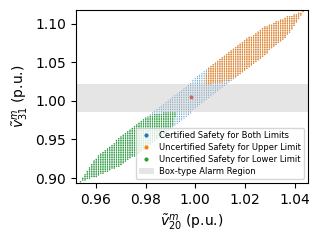

In [18]:
fig, ax = plt.subplots(figsize=(3, 2.25))

ax.scatter(
    feasible_set_x, feasible_set_y,
    edgecolors='none',
    s=0.5,
    label=r'Certified Safety for Both Limits',
    zorder=1
)

ax.scatter(
    unsafe_set_x, unsafe_set_y,
    edgecolors='none',
    s=1,
    label=r"Uncertified Safety for Upper Limit",
    zorder=1
)

ax.scatter(
    unsafe_set_min_x, unsafe_set_min_y,
    edgecolors='none',
    s=1,
    label=r"Uncertified Safety for Lower Limit",
    zorder=1
)

ax.scatter(
    actual_set_x[3], actual_set_y[3],
    s=5,
    marker='*',
    # label=r"On",
    zorder=1
)

# Box coordinates
x_low = v_s_lb[0] + 1
x_upp = v_s_ub[0] + 1
y_low = v_s_lb[1] + 1
y_upp = v_s_ub[1] + 1

# Rectangle patch
rect = patches.Rectangle(
    (x_low, y_low),
    x_upp - x_low,
    y_upp - y_low,
    facecolor="Silver",
    edgecolor="None",
    linestyle="--",
    linewidth=1.5,
    alpha=0.4,
    label=r"Box-type Alarm Region",
    zorder=2
)

ax.add_patch(rect)

# Labels
label_x = fr"$\tilde{{v}}^m_{{{node_obs[0] + 2}}}$ (p.u.)"
label_y = fr"$\tilde{{v}}^m_{{{node_obs[1] + 2}}}$ (p.u.)"

ax.set_xlabel(label_x)
ax.set_ylabel(label_y)
#ax.set_title(f"Target Node #{target_node}", fontsize=15)

ax.tick_params(axis='both')

# Optional but recommended
# ax.axis("equal")

# ============================================================
# Custom legend
# ============================================================
legend_handles = [
    Line2D(
        [], [],
        marker='o',
        linestyle='None',
        markerfacecolor='C0',
        markeredgecolor='none',
        markersize=3,
        label=r'Certified Safety for Both Limits'
    ),

    Line2D(
        [], [],
        marker='o',
        linestyle='None',
        markerfacecolor='C1',
        markeredgecolor='none',
        markersize=3,
        label=r'Uncertified Safety for Upper Limit'
    ),

    Line2D(
        [], [],
        marker='o',
        linestyle='None',
        markerfacecolor='C2',
        markeredgecolor='none',
        markersize=3,
        label=r'Uncertified Safety for Lower Limit'
    ),

    patches.Patch(
        facecolor='Silver',
        edgecolor='None',
        linestyle='--',
        linewidth=1.2,
        alpha=0.4,
        label=r'Box-type Alarm Region'
    )
]

ax.legend(
    handles=legend_handles,
    loc='lower right',
    fontsize=6,
    handlelength=1.8,
    handletextpad=0.6,
    borderpad=0.4,
    labelspacing=0.35
)

#ax.legend(loc="lower right", fontsize=6)


ax.set_xlim([np.min(feasible_set_x) * 0.998, np.max(feasible_set_x) * 1.002])
ax.set_ylim([np.min(feasible_set_y) * 0.998, np.max(feasible_set_y) * 1.002])


#plt.savefig('fig1-2-intro_new2.pdf', dpi=300, bbox_inches='tight')
plt.show()